# Logistic regression

In [37]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [20]:
df = pd.read_csv('..//data//Human_Activity_Recognition_Using_Smartphones_Data-1.csv')

In [22]:
X = df.drop('Activity', axis=1)
y = df['Activity']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [27]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

c:\Users\ARRF\Desktop\Maruthi\torch2.0.1_gpu\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [29]:
y_pred_log = log_reg.predict(X_test)

In [35]:
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f'The accuracy is: {accuracy_log*100}%')

The accuracy is: 98.05825242718447%


In [39]:
class_report = classification_report(y_test, y_pred_log)
print(class_report)

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       597
           SITTING       0.96      0.95      0.95       563
          STANDING       0.95      0.96      0.96       547
           WALKING       0.99      1.00      1.00       539
WALKING_DOWNSTAIRS       1.00      0.99      0.99       420
  WALKING_UPSTAIRS       0.98      1.00      0.99       424

          accuracy                           0.98      3090
         macro avg       0.98      0.98      0.98      3090
      weighted avg       0.98      0.98      0.98      3090



In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred_log)
class_accuracies = {}
classes = df['Activity'].unique()
for i, cls in enumerate(classes):
    true_positives = conf_matrix[i, i]
    total_instances = np.sum(conf_matrix[i, :])
    class_accuracies[cls] = true_positives / total_instances

class_accuracies

{'STANDING': 1.0,
 'SITTING': 0.9467140319715808,
 'LAYING': 0.9597806215722121,
 'WALKING': 0.9981447124304267,
 'WALKING_DOWNSTAIRS': 0.9880952380952381,
 'WALKING_UPSTAIRS': 0.9952830188679245}

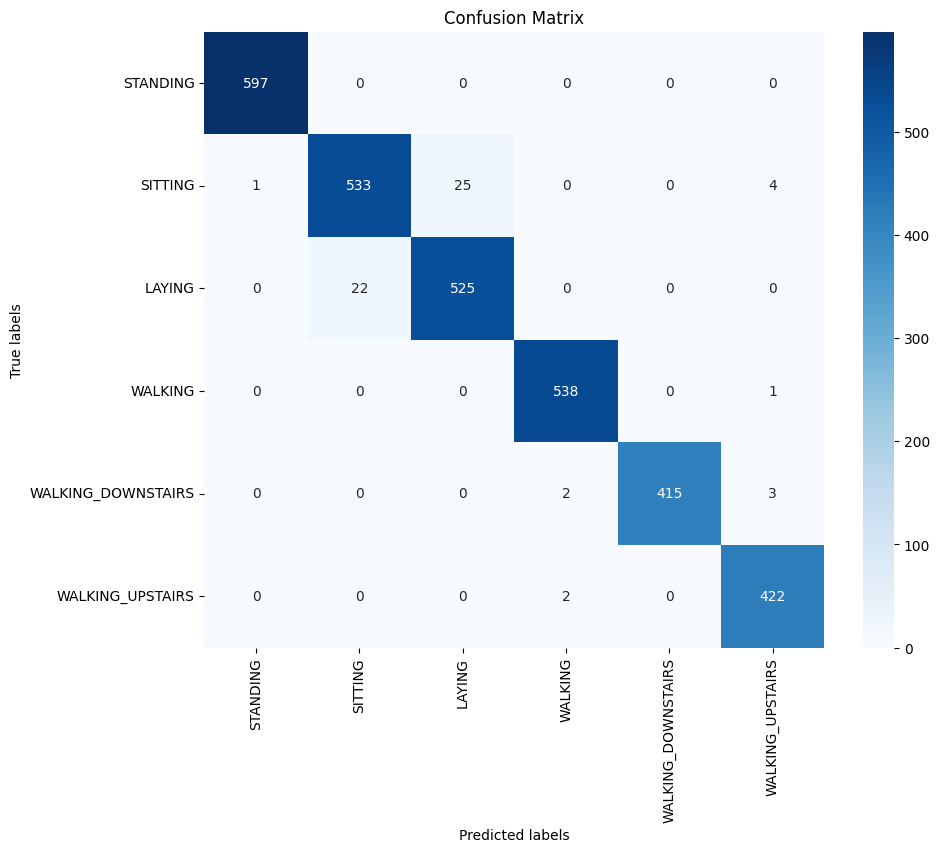

In [44]:
#conf_matrix = confusion_matrix(y_test, y_pred_log, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

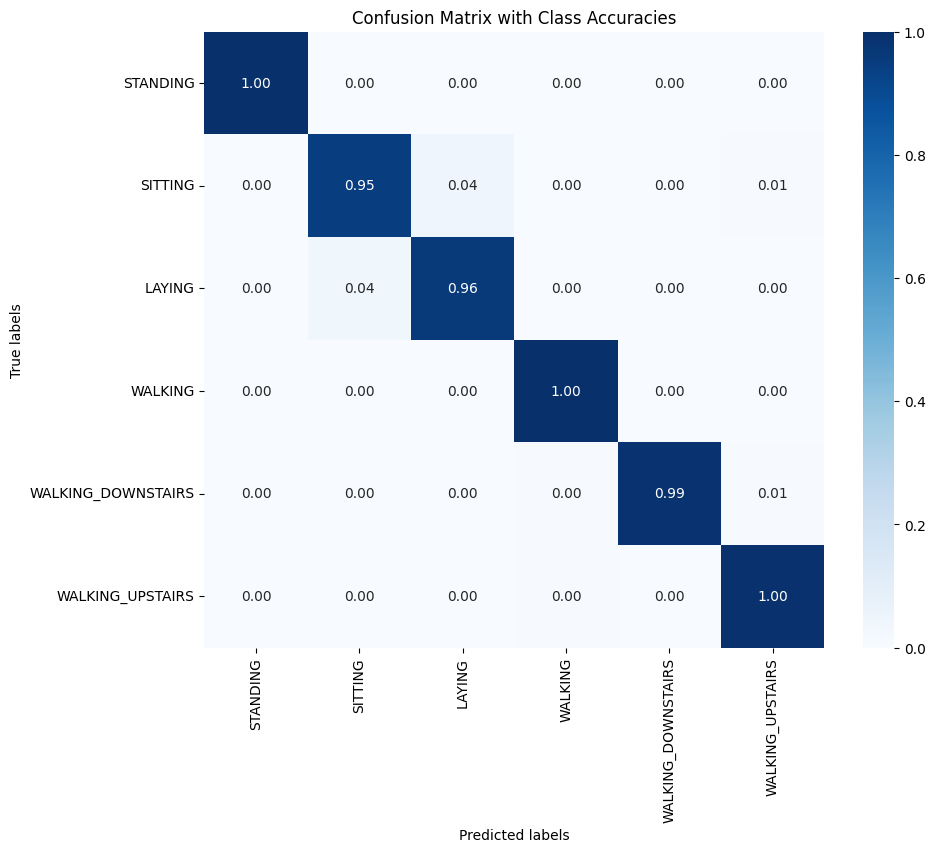

In [45]:
normalized_conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(normalized_conf_matrix, annot=True, fmt=".2f", cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix with Class Accuracies')
plt.show()